## CARD: Training Session 8
### Model implementation with object-orientated programming 

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results
- CatalystBed as Class that implements the model as a DAE

In [1]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np

from src.CatalystBed import (
    CatalystBed,  # this is a recommended model structure of ours using OOP
)

Now setting the initial and boundary conditions:

In [2]:
w_i_in = np.array([1, 0])   # [-]    # 0: A, 1: B
T_in = 300                  # [K]
u_in = 1                    # [m/s]
p_in = 2e5                  # [Pa]
w_i_0 = np.array([1, 0])    # [-]    # 0: A, 1: B
T_0 = 300                   # [K]

Using an array as upper bound of the integral to calculate various timesteps:

In [3]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 100     # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Define DAE using CatalystBed Class:

In [4]:
catBed = CatalystBed(w_i_in, T_in, u_in, p_in)
dae = catBed.create_dae()

Then define and call the integrator to solve the DAE:

In [5]:
options = {"abstol": 1e-13, "reltol": 1e-13}
I = casADi.integrator("I", "idas", dae, t_0, t_i, options)
x_0 = np.zeros(catBed.n_axial * (len(catBed.nu) + 1))
x_0[0 : catBed.n_axial] = w_i_0[0]
x_0[catBed.n_axial : 2 * catBed.n_axial] = w_i_0[1]
x_0[2 * catBed.n_axial :] = T_0
z_0 = np.zeros(catBed.n_axial * 2)
z_0[0 : catBed.n_axial] = u_in
z_0[catBed.n_axial : 2 * catBed.n_axial] = p_in
res_dic = I(x0=x_0, z0=z_0)

Results need to be reshaped like this:

In [6]:
res_x = res_dic["xf"].full()
w_i_res = np.empty(shape=(catBed.n_axial, t_steps, len(catBed.nu)))
T_res = np.empty(shape=(catBed.n_axial, t_steps))
for t in range(t_steps):
    T_res[:, t] = res_x[len(catBed.nu) * catBed.n_axial :, t]
    for comp in range(len(catBed.nu)):
        w_i_res[:, t, comp] = res_x[
            comp * catBed.n_axial : catBed.n_axial * (comp + 1), t
        ]
res_z = res_dic["zf"].full()
u_res = np.empty(shape=(catBed.n_axial, t_steps))
p_res = np.empty(shape=(catBed.n_axial, t_steps))
for t in range(t_steps):
    u_res[:, t] = res_z[: catBed.n_axial, t]
    p_res[:, t] = res_z[catBed.n_axial : 2 * catBed.n_axial, t]

Plot the results:

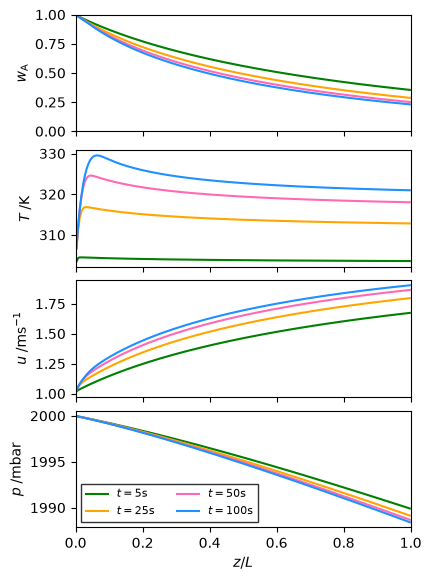

In [7]:
# Create figure and axes of plot
fig, axs = plt.subplots(4, 1, figsize=(4.2, 5.7), constrained_layout=True, sharex=True)

# Plot values
z_c = catBed.f_z_c()
axs[0].plot(z_c, w_i_res[:, 5, 0], color="green")
axs[0].plot(z_c, w_i_res[:, 25, 0], color="orange")
axs[0].plot(z_c, w_i_res[:, 50, 0], color="hotpink")
axs[0].plot(z_c, w_i_res[:, 100, 0], color="dodgerblue")

axs[1].plot(z_c, T_res[:, 5], color="green")
axs[1].plot(z_c, T_res[:, 25], color="orange")
axs[1].plot(z_c, T_res[:, 50], color="hotpink")
axs[1].plot(z_c, T_res[:, 100], color="dodgerblue")

axs[2].plot(z_c, u_res[:, 5], color="green")
axs[2].plot(z_c, u_res[:, 25], color="orange")
axs[2].plot(z_c, u_res[:, 50], color="hotpink")
axs[2].plot(z_c, u_res[:, 100], color="dodgerblue")

axs[3].plot(z_c, p_res[:, 5] * 1e-2, color="green", label=r"$t= 5 \mathregular{s}$")
axs[3].plot(z_c, p_res[:, 25] * 1e-2, color="orange", label=r"$t= 25 \mathregular{s}$")
axs[3].plot(z_c, p_res[:, 50] * 1e-2, color="hotpink", label=r"$t= 50 \mathregular{s}$")
axs[3].plot(
    z_c, p_res[:, 100] * 1e-2, color="dodgerblue", label=r"$t= 100 \mathregular{s}$"
)

# Set axes parameters
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)
axs[0].set_ylabel("$w_{\\mathregular{A}}$")

axs[1].set_ylabel("$T \\; \\mathregular{/K}$")

axs[2].set_ylabel("$u \\; \\mathregular{/ms^{-1}}$")

axs[3].set_ylabel("$p \\; \\mathregular{/mbar}$")
axs[3].set_xlabel("$z/L$")
axs[3].legend(fancybox=False, loc="best", ncol=2, edgecolor="black", fontsize=8)